# **Exercise 1**

In [ ]:
!pip install numpy
!pip install scipy
!pip install matplotlib
!pip install networkx


In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import math
import itertools

In [ ]:
def symmetric_k_regular_graph(num_nodes, degree, show=False):
    """
    num_nodes : number of nodes
    degree    : degree of each node
    show      :  draw the graph
    """

    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    node_list = list(G.nodes)

    half_deg = degree // 2

    # connect each node to its nearest neighbors
    for u in node_list:
        for step in range(1, half_deg + 1):
            v = (u + step) % num_nodes   # circular indexing
            G.add_edge(u, v)

    if show:
        pos = nx.circular_layout(G)
        nx.draw(
            G,
            pos,
            with_labels=True,
            node_color="#83C1FF",
            edgecolors="black",
            node_size=500
        )

    return G


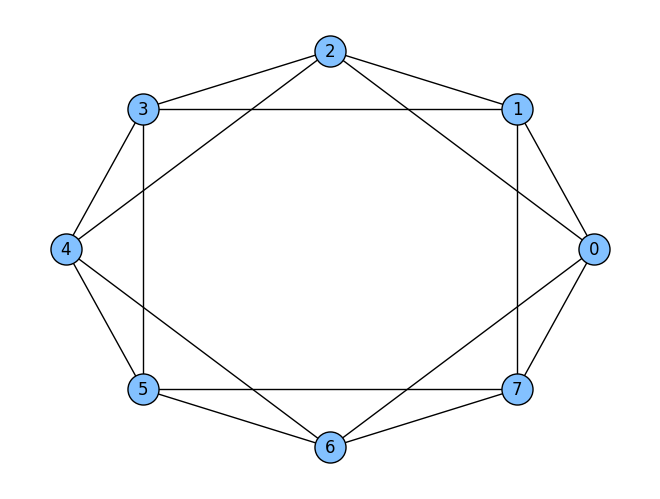

In [ ]:
G=symmetric_k_regular_graph(8, 4, True)

In [ ]:
def Simulate_epidemic(graph, transmission_rate, recovery_rate, num_nodes, num_simulations, initial_infected, num_steps, show_results=False):
    """
    Simulates the spread of an infectious disease.
 Parameters:
      graph (networkx.Graph): A network representing individuals and their contact connections.

      transmission_rate (float): The likelihood that a susceptible individual becomes infected after contact with an infected neighbor.

      recovery_rate (float): The probability that an infected individual recovers at each time step.

      num_nodes (int): The total number of individuals in the network.

      num_simulations (int): The number of independent simulation runs to average the results over.

      initial_infected (int): The number of individuals who are infected at the start of the simulation.

      num_steps (int): The total number of discrete time steps (e.g., weeks) simulated.

      show_results (bool): If set to True, the simulation outcomes are visualized.

  Returns:

     tuple: A tuple containing the average new infections, susceptible individuals, infected individuals, and recovered individuals per week.
    """

    # Initialize matrices to store statistics over the simulation runs
    new_infected = np.zeros((num_simulations, num_steps + 1))
    susceptible_individuals = np.zeros((num_simulations, num_steps + 1))
    infected_individuals = np.zeros((num_simulations, num_steps + 1))
    recovered_individuals = np.zeros((num_simulations, num_steps + 1))

    # Convert the graph to a NumPy array for easier neighbor access
    adjacency_matrix = nx.to_numpy_array(graph)

    # Run the simulations
    for iteration in range(num_simulations):
        # Initialize the state of individuals: 0 = susceptible, 1 = infected
        current_state = np.array([0] * num_nodes)

        # Randomly select initial infected individuals
        indices = random.sample(range(num_nodes), initial_infected)
        current_state[indices] = 1  # Mark these individuals as infected

        # Record initial statistics
        infected_individuals[iteration][0] = initial_infected
        susceptible_individuals[iteration][0] = num_nodes - initial_infected

        # Simulate each week
        for step in range(1, num_steps + 1):
            # Store the previous state for comparison
            previous_state = current_state.copy()

            # Update the state of each individual
            for agent, state in enumerate(previous_state):
                if state == 0:  # If the individual is susceptible
                    # Find neighboring nodes (connected individuals)
                    neighbors = np.arange(num_nodes)[np.array(adjacency_matrix[agent, :]).flatten() != 0]
                    infected_neighbors_count = 0

                    # Count the number of infected neighbors
                    for neighbor in neighbors:
                        if previous_state[neighbor] == 1:
                            infected_neighbors_count += 1

                    # Calculate the probability of infection based on the number of infected neighbors
                    infection_probability = 1 - (1 - transmission_rate) ** infected_neighbors_count

                    # Determine if the susceptible individual becomes infected
                    if infection_probability > random.random():
                        new_infected[iteration][step] += 1  # Increment the count of new infections
                        current_state[agent] = 1  # Update the individual's state to infected

                elif state == 1:  # If the individual is infected
                    # Check if the infected individual recovers
                    if recovery_rate > random.random():
                        current_state[agent] = -1  # Update the state to recovered

            # Update statistics for the current week
            recovered_individuals[iteration][step] = (current_state == -1).sum()
            infected_individuals[iteration][step] = (current_state == 1).sum()
            susceptible_individuals[iteration][step] = (current_state == 0).sum()

    # Calculate the average statistics over all simulations
    avg_new_inf_week = new_infected.mean(axis=0)  # Average new infections per week
    avg_tot_sus_week = susceptible_individuals.mean(axis=0)
    avg_tot_inf_week = infected_individuals.mean(axis=0)
    avg_tot_rec_week = recovered_individuals.mean(axis=0)


    if show_results:
        plt.figure()
        x = range(num_steps + 1)

        # Plot the average Susceptible, infected, new infected and recovered individuals
        plt.plot(x, avg_new_inf_week, color='orange', label="New Infected")
        plt.plot(x, avg_tot_inf_week, color='red', label="Infected")
        plt.plot(x, avg_tot_rec_week, color='green', label="Recovered")
        plt.plot(x, avg_tot_sus_week, color='blue', label="Susceptible")



        plt.xlabel("Week")
        plt.ylabel("Number of Individuals")
        plt.title("Average Number of Susceptible , Infected, new infected and Recovered Individuals Over Time")
        plt.legend()
        plt.show()


        plt.plot(x, avg_tot_sus_week, color='blue', label="Susceptible")
        plt.xlabel("Week")
        plt.ylabel("Number of Individuals")
        plt.title("Average Number of Susceptible Individuals Over Time")


    return avg_new_inf_week, avg_tot_sus_week, avg_tot_inf_week, avg_tot_rec_week

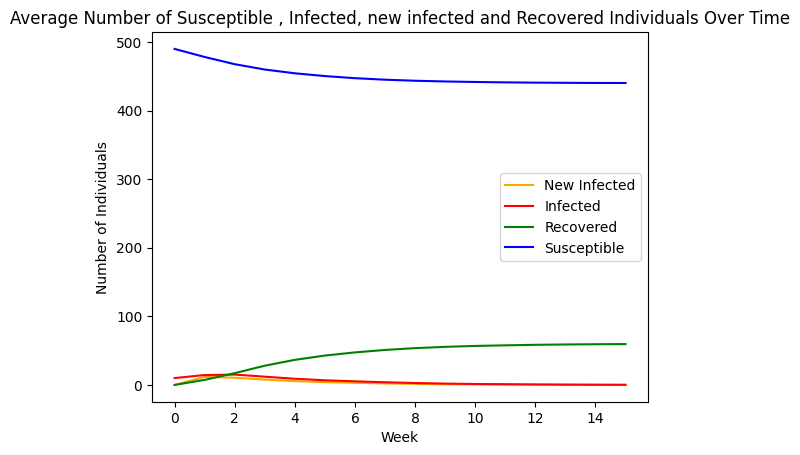

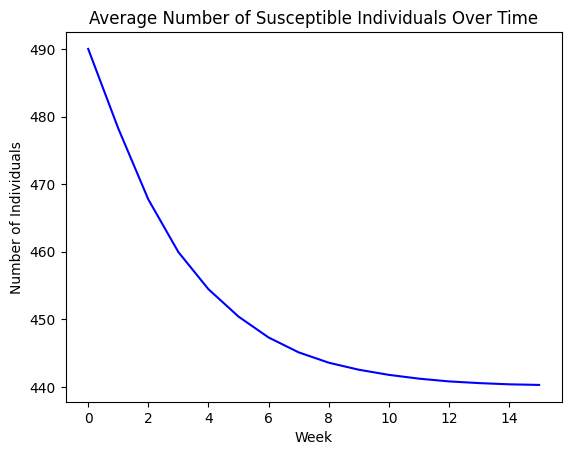

In [ ]:
beta = 0.3
rho = 0.7
n = 500
k = 4
N = 100
inf_t0 = 10
n_step = 15 #weeks
G1 = symmetric_k_regular_graph(n, k)
avg_newly_infected,avg_suspected,avg_infected,avg_recovered= Simulate_epidemic(G1,beta,rho,n,N,inf_t0,n_step,show_results=True)

In [ ]:
print("The average number of newly infected individuals each week")
avg_newly_infected

The average number of newly infected individuals each week


array([ 0.  , 12.19, 10.52,  7.64,  5.31,  4.03,  2.68,  1.85,  1.47,
        1.05,  0.8 ,  0.58,  0.39,  0.28,  0.18,  0.14])

In [ ]:
print("The average number of susceptible individuals per week")
avg_suspected

The average number of susceptible individuals per week


array([490.  , 477.81, 467.29, 459.65, 454.34, 450.31, 447.63, 445.78,
       444.31, 443.26, 442.46, 441.88, 441.49, 441.21, 441.03, 440.89])

In [ ]:
print("The average number of infected individuals per week")
avg_infected

The average number of infected individuals per week


array([10.  , 15.  , 14.83, 11.88,  8.88,  6.72,  4.55,  3.44,  2.6 ,
        1.84,  1.33,  0.93,  0.69,  0.48,  0.33,  0.23])

In [ ]:
print("The average number of recovered individuals per week")
avg_recovered

The average number of recovered individuals per week


array([ 0.  ,  7.19, 17.88, 28.47, 36.78, 42.97, 47.82, 50.78, 53.09,
       54.9 , 56.21, 57.19, 57.82, 58.31, 58.64, 58.88])

In [ ]:
def generate_preferential_attachment_graph(total_nodes, k):
    """
    Generates a graph based on the preferential attachment model.

    Parameters:
    total_nodes (int): The total number of nodes in the resulting network.
    k (int): The number of edges each new node will create (must be even).
    display_graph (bool): If set to True, visualizes the generated network.

    Returns:
    networkx.Graph: The generated preferential attachment graph.
    """
    graph = nx.complete_graph(k + 1)

    alternate = True
    for new_node in range(k + 1, total_nodes):
        nodes = list(graph.nodes())
        # Calculate the degree of each node in the current graph
        degrees = np.array([graph.degree(v) for v in nodes], dtype=float)
        # Calculate the probability distribution based on the degrees
        probs = degrees / degrees.sum()# Normalize

        if k % 2 == 0:
            m = k // 2
        else:
            m = math.floor(k/2) if alternate else math.ceil(k/2)
            alternate = not alternate
        # Randomly select neighbors based on calculated probabilities
        chosen = np.random.choice(nodes, size=m, replace=False, p=probs)
        # Connect the new node to the selected neighbors
        graph.add_node(new_node)
        graph.add_edges_from((new_node, v) for v in chosen)

    return graph

In [ ]:
G2 = generate_preferential_attachment_graph(500,6)

In [ ]:
np.array([d for _,d in G.degree()]).mean()

np.float64(4.0)

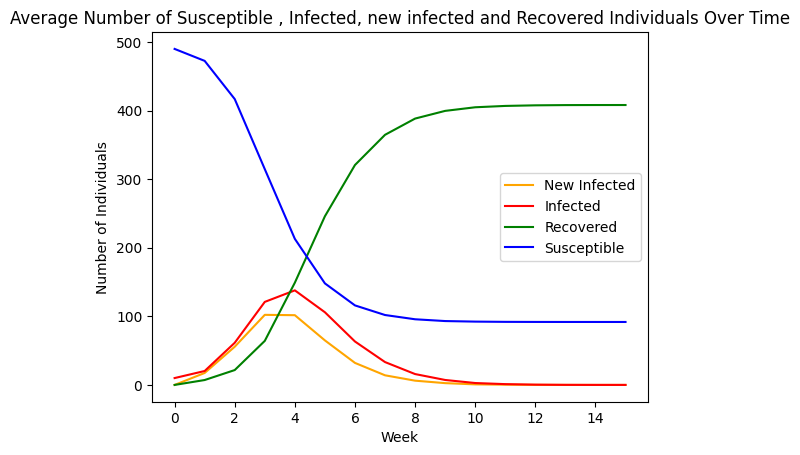

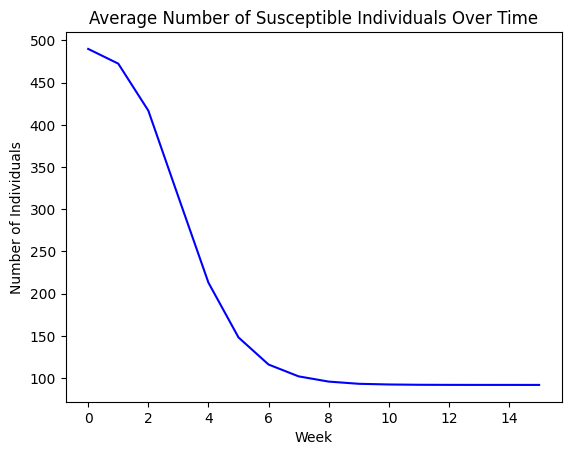

In [ ]:
beta = 0.3
rho = 0.7
n = 500
k = 6
N = 100
inf_t0 = 10
n_step = 15
G2 = generate_preferential_attachment_graph(n,k)
a,b,c,d= Simulate_epidemic(G2,beta,rho,n,N,inf_t0,n_step,show_results=True)

In [ ]:
a

array([ 0.  , 10.45, 29.21, 50.85, 58.56, 51.95, 39.39, 24.46, 14.31,
        8.2 ,  4.53,  2.33,  1.28,  0.65,  0.36,  0.19])

problem 1.3

In [ ]:
def Simulate_epidemic_vaccine_model(graph, infection_rate, recovery_rate, total_nodes, num_simulations, initial_infected, num_steps, initial_vaccinated=0, display_results=False):
    """
    Simulates  with vaccination intervention.

    Parameters:
    graph (networkx.Graph): The graph representing the population.
    infection_rate (float): The probability of infection per contact with an infected individual.
    recovery_rate (float): The probability of recovery for infected individuals.
    total_nodes (int): The total number of nodes (individuals) in the graph.
    num_simulations (int): The number of simulation runs to perform.
    initial_infected (int): The initial number of infected individuals.
    num_steps (int): The number of time steps (weeks) to simulate.
    initial_vaccinated (int): The initial number of vaccinated individuals.
    display_results (bool): If True, displays the simulation results.

    Returns:
    tuple: A tuple containing the average new infections, susceptible individuals, infected individuals, and recovered individuals per week.
    """

    # Initialize matrices to store statistics over the simulation runs
    new_infected_count = np.zeros((num_simulations, num_steps + 1))
    susceptible_count = np.zeros((num_simulations, num_steps + 1))
    infected_count = np.zeros((num_simulations, num_steps + 1))
    recovered_count = np.zeros((num_simulations, num_steps + 1))

    vaccinated_count = np.zeros((num_simulations, num_steps + 1))


    # Convert the graph to a NumPy array for easier neighbor access
    adjacency_matrix = nx.to_numpy_array(graph)

    """
    Individual state encoding:
    S = 0 (Susceptible)
    I = 1 (Infected)
    R = -1 (Recovered)
    V = 2 (Vaccinated)
    """
    for simulation in range(num_simulations):
        # Initialize the state of all individuals to susceptible
        current_state = np.array([0] * total_nodes)

        # Randomly select the initial infected individuals
        infected_indices = random.sample(range(total_nodes), initial_infected)
        current_state[infected_indices] = 1  # Update their state to infected
        new_infected_count[simulation][0] = initial_infected
        infected_count[simulation][0] = initial_infected
        susceptible_count[simulation][0] = total_nodes - initial_infected

        # If initial_vaccinated is greater than 0, randomly select non-infected individuals to vaccinate
        if initial_vaccinated > 0:
            num_to_vaccinate = initial_vaccinated

            # Identify individuals that can be vaccinated (not infected)
            candidates_for_vaccination = np.arange(len(current_state))[current_state != 1]

            # Randomly select individuals to vaccinate
            vaccinated_indices = np.random.choice(candidates_for_vaccination, size=int(num_to_vaccinate), replace=False)
            current_state[vaccinated_indices] = 2  # Update their state to vaccinated

        # Main simulation loop for each time step (week)
        for week in range(1, num_steps + 1):
            previous_state = current_state.copy()  # Store the previous state for reference

            ## Determine how many individuals are vaccinated during this week
            num_to_vaccinate = to_vacc[week - 1]

            if int(num_to_vaccinate) > 0:
                # Select individuals who are not already vaccinated
                candidates_for_vaccination = np.arange(len(current_state))[current_state != 2]

                # Randomly select individuals to vaccinate
                vaccinated_indices = np.random.choice(candidates_for_vaccination, size=int(num_to_vaccinate), replace=False)

                # Update vaccination status
                previous_state[vaccinated_indices] = 2
                current_state[vaccinated_indices] = 2

            # Update the state of each individual based on infection and recovery
            for individual_index, state in enumerate(previous_state):
                if state == 0:  #   susceptible
                  # Identify neighboring individuals
                    neighbors = np.arange(total_nodes)[np.array(adjacency_matrix[individual_index, :]).flatten() != 0]
                    infected_neighbors_count = 0

                    # Count infected neighbors
                    for neighbor in neighbors:
                        if previous_state[neighbor] == 1:
                            infected_neighbors_count += 1

                    # Compute infection probability from all infected neighbors
                    infection_probability = 1 - (1 - infection_rate) ** infected_neighbors_count

                    # Determine if the individual becomes infected
                    if infection_probability > np.random.rand():
                        new_infected_count[simulation][week] += 1
                        current_state[individual_index] = 1  # Update the individual's state to infected
                    continue

                if state == 1:  #  already infected
                    # Check if the infected individual recovers
                    if recovery_rate > np.random.rand():
                        current_state[individual_index] = -1  # Update the state to recovered

            # Update population counts for the current week
            recovered_count[simulation][week] = (current_state == -1).sum()
            infected_count[simulation][week] = (current_state == 1).sum()
            susceptible_count[simulation][week] = (current_state == 0).sum()

            vaccinated_count[simulation][week] = (current_state == 2).sum()



    avg_new_infections = new_infected_count.mean(axis=0)
    avg_total_susceptible = susceptible_count.mean(axis=0)
    avg_total_infected = infected_count.mean(axis=0)
    avg_total_recovered = recovered_count.mean(axis=0)

    avg_total_vaccinated = vaccinated_count.mean(axis=0)



    if display_results:
        plt.figure()
        x = range(num_steps + 1)

        # Plot the average new infections, infected, and recovered individuals
        plt.plot(x, avg_new_infections, color='orange', label="New Infected")
        plt.plot(x, avg_total_infected, color='red', label="Infected")
        plt.plot(x, avg_total_recovered, color='green', label="Recovered")
        plt.plot(x, avg_total_vaccinated, color='purple',label="Vaccinated")



        plt.xlabel("Week")
        plt.ylabel("Number of Individuals")
        plt.title("Average Number of Susceptible, Infected, and Recovered Individuals Over Time")
        plt.legend()
        plt.show()


        plt.plot(x, avg_total_susceptible, color='blue', label="Susceptible")
        plt.xlabel("Week")
        plt.ylabel("Number of Individuals")
        plt.title("Average Number of Susceptible Individuals Over Time")


    return avg_new_infections, avg_total_susceptible, avg_total_infected, avg_total_recovered, avg_total_vaccinated


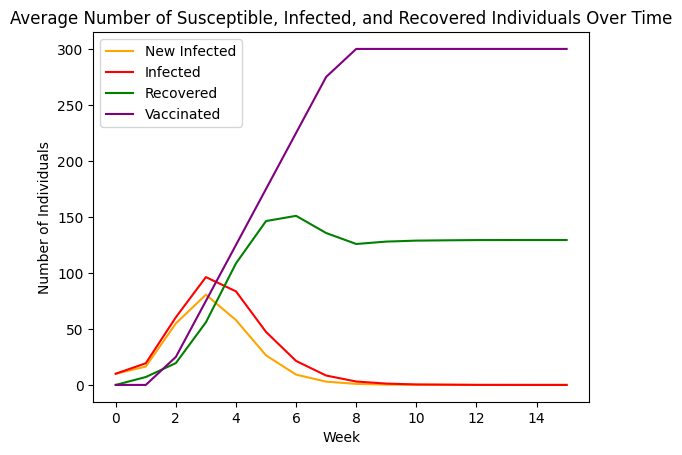

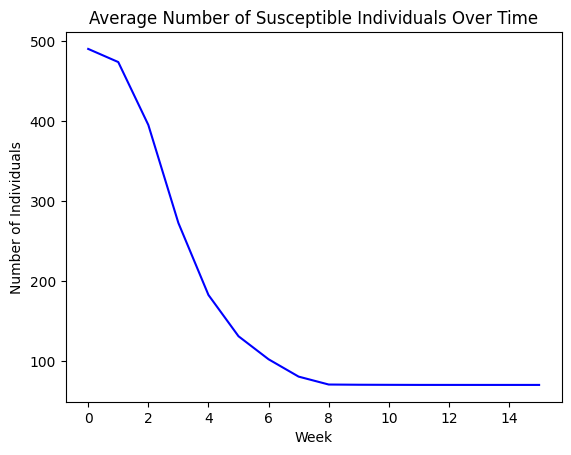

In [ ]:
beta = 0.3
rho = 0.7
n = 500
k = 6
N = 100
inf_t0 = 10
n_step = 15 # weeks

vacc = np.array([0,0, 5, 15, 25, 35, 45, 55, 60, 60, 60, 60, 60, 60, 60, 60]) # double zero because the first is the initial condition
# distribute vaccination
to_vacc = np.diff(vacc)
to_vacc = to_vacc * n / 100
vacc = vacc * n /100


G3 = generate_preferential_attachment_graph(n,k)
a,b,c,d,e= Simulate_epidemic_vaccine_model(G3,beta,rho,n,N,inf_t0,n_step,display_results=True)

In [ ]:
# Function to generate parameter combinations based on initial parameters and their deltas
def generate_parameter_combinations(initial_params, param_deltas):
    """
    Generates all combinations of parameters based on the initial values and their deltas.

    Parameters:
    initial_params (tuple): The initial parameter values.
    param_deltas (tuple): The deltas to vary each parameter by.
    beta (float): Initial transmission rate.
    ro (float): Initial recovery rate.
    delta_k (int): Step size for the average degree.
    delta_beta (float): Step size for the transmission rate.
    delta_ro (float): Step size for the recovery rate.

    Returns:
    tuple: Best parameters (beta, k, ro) and the state of the best simulation.
    """
    combinations = []
    for initial, delta in zip(initial_params, param_deltas):
        # For each parameter, create a list of three values: (initial - delta, initial, initial + delta)
        combinations.append([initial - delta, initial, initial + delta])
    # lists to get all combinations
    return list(itertools.product(*combinations))


#compare two tuples for equality after sorting
def equal(t1, t2):
    """
    Compares two tuples to see if they contain the same elements.

    Parameters:
    t1 (tuple): The first tuple to compare.
    t2 (tuple): The second tuple to compare.

    Returns:
    bool: True if the tuples contain the same elements, False otherwise.
    """
    return sorted(t1) == sorted(t2)


# Initial parameters
beta = 0.3
rho = 0.6
k = 10

# Deltas
delta_beta = delta_rho = 0.1
delta_k = 1

# Pack the initial parameters and their deltas into tuples
initial_parameters = (k, beta, rho)
parameter_deltas = (delta_k, delta_beta, delta_rho)

# Generate all combinations of parameters
parameter_combinations = generate_parameter_combinations(initial_parameters, parameter_deltas)

# Actual infected data for comparison
actual_infected = [1, 1, 3, 5, 9, 17, 32, 32, 17, 5, 2, 1, 0, 0, 0, 0]


n = 934  # Total population size
N = 10   # Number of simulations
n_steps = 15  # (weeks)

### Vaccination data

vaccination_schedule = np.array([5, 9, 16, 24, 32, 40, 47, 54, 59, 60, 60, 60, 60, 60, 60])
if len(vaccination_schedule) == n_steps:
    vaccination_schedule = np.append(vaccination_schedule, vaccination_schedule[-1])

vaccination_counts = vaccination_schedule * n / 100  # Total vaccinated individuals
to_vaccinate = np.diff(vaccination_counts)  # Number of individuals to vaccinate each week
vaccination_schedule = vaccination_schedule * n / 100  # Adjusted vaccination schedule




initial_infected_count = actual_infected[0]
initial_vaccinated_count = vaccination_counts[0]

# best configuration and error
best_rmse = np.inf
best_config = ()


while True:
    errors = []
    estimations = []  # store estimations for each configuration

    for k_value, beta_value, rho_value in parameter_combinations:
        graph = generate_preferential_attachment_graph(n, int(k_value))


        estimated_infected, avg_susceptible, avg_infected, avg_recovered, avg_vaccinated = Simulate_epidemic_vaccine_model(graph, beta_value, rho_value, n, N, initial_infected_count, n_steps, initial_vaccinated_count)

        # Store the estimations and calculate the error compared to actual data
        estimations.append([estimated_infected, avg_susceptible, avg_infected, avg_recovered])
        error = math.sqrt(np.square(np.subtract(actual_infected[1:], estimated_infected[1:])).mean())
        errors.append(error)

    #  (RMSE)
    idx = np.argmin(errors)
    min_config = parameter_combinations[idx]
    rmse = errors[idx]

    # Update the global best configuration if improvement is found
    if best_rmse > rmse:
        best_rmse = rmse
        global_best_configuration = min_config
        global_estimation = estimations[idx]

    # Stop if the best configuration hasn't changed
    if equal(min_config, best_config):
        break

    # Generate a new set of combinations based on the best configuration found in this iteration
    best_config = min_config
    parameter_combinations = generate_parameter_combinations(best_config, parameter_deltas)

In [ ]:
parameter_combinations

[(7, 0.09999999999999998, 0.7),
 (7, 0.09999999999999998, 0.7999999999999999),
 (7, 0.09999999999999998, 0.8999999999999999),
 (7, 0.19999999999999998, 0.7),
 (7, 0.19999999999999998, 0.7999999999999999),
 (7, 0.19999999999999998, 0.8999999999999999),
 (7, 0.3, 0.7),
 (7, 0.3, 0.7999999999999999),
 (7, 0.3, 0.8999999999999999),
 (8, 0.09999999999999998, 0.7),
 (8, 0.09999999999999998, 0.7999999999999999),
 (8, 0.09999999999999998, 0.8999999999999999),
 (8, 0.19999999999999998, 0.7),
 (8, 0.19999999999999998, 0.7999999999999999),
 (8, 0.19999999999999998, 0.8999999999999999),
 (8, 0.3, 0.7),
 (8, 0.3, 0.7999999999999999),
 (8, 0.3, 0.8999999999999999),
 (9, 0.09999999999999998, 0.7),
 (9, 0.09999999999999998, 0.7999999999999999),
 (9, 0.09999999999999998, 0.8999999999999999),
 (9, 0.19999999999999998, 0.7),
 (9, 0.19999999999999998, 0.7999999999999999),
 (9, 0.19999999999999998, 0.8999999999999999),
 (9, 0.3, 0.7),
 (9, 0.3, 0.7999999999999999),
 (9, 0.3, 0.8999999999999999)]

In [ ]:
best_config


(8, 0.19999999999999998, 0.7999999999999999)

In [ ]:
best_rmse

4.386114453591015

In [ ]:
vaccination_counts

array([ 46.7 ,  84.06, 149.44, 224.16, 298.88, 373.6 , 438.98, 504.36,
       551.06, 560.4 , 560.4 , 560.4 , 560.4 , 560.4 , 560.4 , 560.4 ])

In [ ]:
vaccination_counts = np.append(vaccination_counts, vaccination_counts[-1])

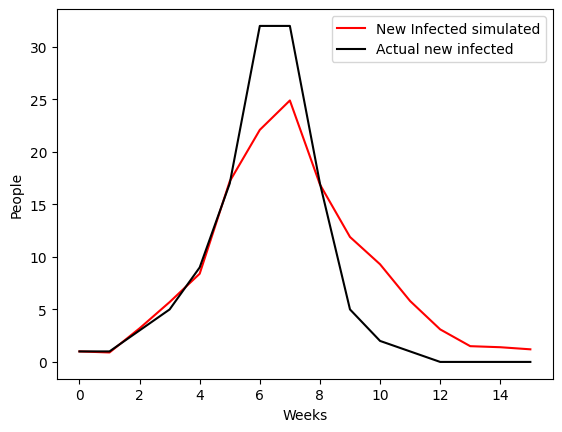

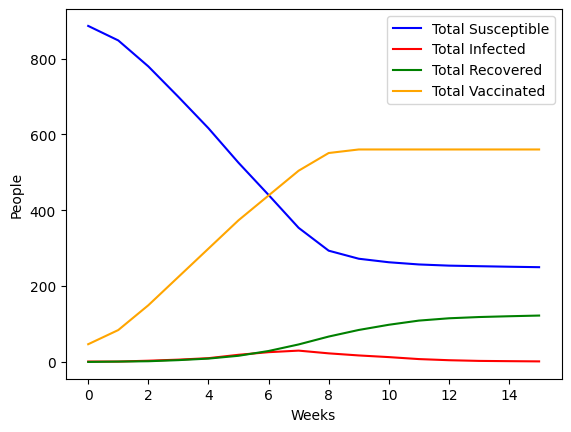

'\nfor data_to_plot, label, color in zip(global_estimation, labels, plot_colors):\n    if label == labels[0]:  #  new infections\n        plt.xlabel("Weeks")\n        plt.ylabel("People")\n        plt.plot(x_values, data_to_plot, color=color, label=label)  # Plot simulated new infections\n        plt.plot(x_values, actual_infected, color="red", label="Actual New Infected")  #  actual new infections\n        plt.legend()\n        plt.show()\n    else:\n        plt.plot(x_values, data_to_plot, color=color, label=label)  # Plot other data series\n\n# Plot total vaccinated individuals\nplt.plot(x_values, vaccination_counts, color="orange", label="Total Vaccinated")\nplt.xlabel("Weeks")\nplt.ylabel("People")\nplt.legend()\nplt.show()\n'

In [ ]:
# Extract estimated values from the global estimation tuple
estimated_infected, avg_total_susceptible, avg_total_infected, avg_total_recovered = global_estimation


plot_colors = ["g", "b", "r", "g", "b"]
labels = ["New Infected (Simulated)", "Total Susceptible", "Total Infected", "Total Recovered"]

I = np.array(avg_total_infected)
R = np.array(avg_total_recovered)
V = np.array(vaccination_counts)  # length 16
L = min(len(I), len(R), len(V))
I = I[:L]
R = R[:L]
V = V[:L]

S_correct = n - I - R - V
x_values = range(L)

#x_values = range(n_step + 1)  # (weeks)

plt.figure()

plt.plot(x_values, estimated_infected[:L], color="red", label="New Infected simulated")
plt.plot(x_values, np.array(actual_infected)[:L], color="black", label="Actual new infected")
plt.xlabel("Weeks")
plt.ylabel("People")
plt.legend()
plt.show()


plt.figure()

plt.plot(x_values, S_correct, color="blue", label="Total Susceptible")
plt.plot(x_values, I, color="red", label="Total Infected")
plt.plot(x_values, R, color="green", label="Total Recovered")
plt.plot(x_values, V, color="orange", label="Total Vaccinated")

plt.xlabel("Weeks")
plt.ylabel("People")
plt.legend()
plt.show()


# **Exercise 2**

## Exercise Summary: Network Games and Dynamics

We consider a network game with a finite set of players  
$$
\mathcal{V} = \{1,2,\dots,n\}, \quad n = 3,
$$
and binary action space
$$
\mathcal{A} = \{-1,+1\}.
$$

Players are divided into two classes:
- **Coordination players** $$ \mathcal{V}_1 = \{1,\dots,n_1\} $$
- **Anti-coordination players** $$ \mathcal{V}_2 = \{n_1+1,\dots,n\} $$

Each player’s utility depends on the actions of all other players:
- Players in $ \mathcal{V}_1 $ prefer to **match** the actions of others (coordination).
- Players in $ \mathcal{V}_2 $ prefer to **differ** from the actions of others (anti-coordination).

The objectives of the exercise are:
1. To determine all **pure Nash equilibria** of the game for different values of $ n_1 $.
2. To study the **asynchronous best response dynamics** and represent the induced Markov chain.
3. To analyze the long-run behavior of the dynamics starting from a given initial condition.
4. To study the **noisy best response dynamics** (logit choice) and characterize its **vanishing-noise limit**.


In [ ]:
import itertools
import numpy as np
import math

## Utilities

For an action profile $ x \in \{-1,+1\}^3 $, the utility of player $i$ is:
$$
u_i(x) =
\begin{cases}
\sum_{j\neq i} \mathbf{1}\{x_i = x_j\}, & i \in \mathcal V_1 \\
\sum_{j\neq i} \mathbf{1}\{x_i \neq x_j\}, & i \in \mathcal V_2
\end{cases}
$$

Thus:
- coordination players prefer matching others;
- anti-coordination players prefer choosing a different action.


In [ ]:
## State space for n=3

ACTIONS = [1, -1]  # +1, -1
STATES = list(itertools.product(ACTIONS, repeat=3))
idx = {s: i for i, s in enumerate(STATES)}

def utilities(x, n1):   #n1: number of coordination players.

    u = []
    for i in range(3):
        if i < n1:  # coordination
            u_i = sum(1 for j in range(3) if j != i and x[j] == x[i])
        else:       # anti-coordination
            u_i = sum(1 for j in range(3) if j != i and x[j] != x[i])
        u.append(u_i)
    return tuple(u)

def best_responses(x, n1, i):   #Return list of best-response actions for player i in state x.
    vals = []
    for a in ACTIONS:
        x2 = list(x)
        x2[i] = a
        vals.append((utilities(tuple(x2), n1)[i], a))
    m = max(v for v, a in vals)
    return [a for v, a in vals if v == m]

## Pure Nash Equilibria

For \( n=3 \), the pure Nash equilibria are:

- \( n_1 = 3 \):  
  \((+,+,+)\), \((-,-,-)\)

- \( n_1 = 2 \):  
  \((+,+,-)\), \((-,-,+)\)

- \( n_1 = 1 \):  
  \((+,+,-), (-,+,-), (+,-,+), (-,-,+)\)

- \( n_1 = 0 \):  
  All six profiles with a 2–1 split; consensus states are not equilibria.


In [ ]:
def pure_NE(n1):
    NE = []
    for x in STATES:
        ok = True
        for i in range(3):
            br = best_responses(x, n1, i)
            if x[i] not in br:
                ok = False
                break
        if ok:
            NE.append(x)
    return NE

## Asynchronous Best Response Dynamics

We study an asynchronous best response process defined as follows:
1. At each time step, one player is selected uniformly at random.
2. The selected player updates their action to a best response.
3. If multiple best responses exist, one is chosen uniformly at random.

This induces a finite-state **Markov chain** on the state space
$
\{-1,+1\}^3
$
with transition probabilities determined by best response updates.

The long-run behavior of the chain depends on the game structure:
- Absorbing states correspond to pure Nash equilibria.
- Transient states are eventually left with probability one.


In [ ]:
def P_async_BR(n1):      #Discrete-time asynchronous best response:
                         # pick i uniformly in {0,1,2}
                         # update x_i to a best response; if tie, choose uniformly among BRs

    P = np.zeros((8, 8))
    for x in STATES:
        s = idx[x]
        for i in range(3):
            br = best_responses(x, n1, i)
            for a in br:
                x2 = list(x)
                x2[i] = a
                t = idx[tuple(x2)]
                P[s, t] += (1/3) * (1/len(br))
    return P

def transition_graph(P):  #Return adjacency list with probabilities > 0.
    graph = {}
    for s, x in enumerate(STATES):
        outs = []
        for t, y in enumerate(STATES):
            if P[s, t] > 1e-12:
                outs.append((y, P[s, t]))
        graph[x] = outs
    return graph

def absorbing_limit_from_initial(P, x0):   #If chain has absorbing states: compute absorption probabilities.
                                           #Otherwise: compute stationary distribution (if unique on recurrent class),
                                           #and return that as the long-run limit (typical for irreducible recurrent class).
    n = P.shape[0]
    # absorbing: only self-loop with prob 1
    absorbing = [i for i in range(n) if np.isclose(P[i, i], 1.0) and np.isclose(P[i].sum(), 1.0)]
    start = idx[x0]

    if absorbing:
        transient = [i for i in range(n) if i not in absorbing]
        Q = P[np.ix_(transient, transient)]
        R = P[np.ix_(transient, absorbing)]
        I = np.eye(len(transient))
        N = np.linalg.inv(I - Q)
        B = N @ R  # absorption probs from each transient state

        if start in absorbing:
            probs = np.zeros(len(absorbing))
            probs[absorbing.index(start)] = 1.0
        else:
            probs = B[transient.index(start)]

        return {
            "type": "absorbing",
            "absorbing_states": [STATES[i] for i in absorbing],
            "absorption_probs": probs
        }

    # otherwise compute stationary distribution via constrained least squares
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    pi = np.maximum(pi, 0)
    pi = pi / pi.sum()

    return {
        "type": "stationary",
        "stationary": pi
    }


## Long-Run Behavior of the Dynamics

### **Case \( n_1 = 3 \) (All Coordination)**

The Markov chain has two absorbing states:
$$
(+,+,+), \quad (-,-,-)
$$

Starting from the initial condition:
$$
X(0) = (+1,-1,+1),
$$
the chain converges to:
$$
\mathbb{P}\big(X(t) = (+,+,+)\big) \to \frac{2}{3}, \quad
\mathbb{P}\big(X(t) = (-,-,-)\big) \to \frac{1}{3}.
$$

All other states have zero limiting probability.


### **Case \( n_1 = 0 \) (All Anti-Coordination)**

The fully aligned states are transient.
The six split states form a recurrent communicating class.

Starting from any initial condition (including \( (+,-,+) \)), the limiting distribution is:
$$
\mathbb{P}\big(X(t) = x\big) \to \frac{1}{6}
\quad \text{for each split state } x,
$$
and zero on the consensus states.

Thus, the limit distribution is uniform over the Nash equilibria.

---


## Noisy Best Response Dynamics and Vanishing-Noise Limit

We also consider a **noisy best response (logit) dynamics**:
$$
\mathbb{P}(x_i = a) \propto \exp\big(\beta\,u_i(a,x_{-i})\big),
$$
where $ \beta\ > 0 $ is the inverse noise parameter.

- For finite $ \beta $, the induced Markov chain is irreducible and has a unique stationary distribution.
- As $ \beta \to \infty $, players choose best responses with probability approaching one.

### Vanishing-Noise Limit

- **\( n_1 = 3 \)**:
  $$
  \pi_\beta \xrightarrow[\beta\to\infty]{}
  \tfrac12 \delta_{(+,+,+)} + \tfrac12 \delta_{(-,-,-)}
  $$

- **\( n_1 = 0 \)**:
  $$
  \pi_\beta \xrightarrow[\beta\to\infty]{}
  \text{Uniform distribution over the six split states}
  $$

These limits coincide with the long-run behavior of the deterministic best response dynamics.


In [ ]:
def P_logit(n1, beta):    #Logit noisy best response:
                          #pick i uniformly
                          #choose a in {+1,-1} with prob proportional to exp(beta * u_i(a, x_-i))
    P = np.zeros((8, 8))
    for x in STATES:
        s = idx[x]
        for i in range(3):
            vals = []
            for a in ACTIONS:
                x2 = list(x)
                x2[i] = a
                vals.append(utilities(tuple(x2), n1)[i])

            mx = max(vals)
            expv = [math.exp(beta * (v - mx)) for v in vals]  # stable softmax
            Z = sum(expv)
            probs = [e / Z for e in expv]  # corresponds to a=+1 then a=-1

            for a, p in zip(ACTIONS, probs):
                x2 = list(x)
                x2[i] = a
                t = idx[tuple(x2)]
                P[s, t] += (1/3) * p
    return P

def stationary_distribution(P):  #Compute stationary distribution pi s.t. pi = pi P (unique for ergodic chains).
    n = P.shape[0]
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    pi = np.maximum(pi, 0)
    return pi / pi.sum()


In [ ]:
def print_transition_graph(P, title=""):
    print("\n" + title)
    for x in STATES:
        outs = [(y, P[idx[x], idx[y]]) for y in STATES if P[idx[x], idx[y]] > 1e-12]
        outs_str = ", ".join([f"{y}:{p:.3f}" for y, p in outs])
        print(f"{x} -> {outs_str}")


In [ ]:
if __name__ == "__main__":
    x0 = (1, -1, 1)


     # --- Transition graphs (requested by the exercise) ---
    P = P_async_BR(3)
    print_transition_graph(P, title="Transition graph (async BR), n1=3")

    P = P_async_BR(0)
    print_transition_graph(P, title="Transition graph (async BR), n1=0")

    for n1 in [3, 2, 1, 0]:
        print(f"\n n1 = {n1} ")
        NE = pure_NE(n1)
        print("Pure Nash equilibria:")
        for s in NE:
            print(" ", s)

    # (b1) n1=3, async BR, limit from x0
    n1 = 3
    P = P_async_BR(n1)
    result = absorbing_limit_from_initial(P, x0)
    print("\n (b1) Asynchronous BR, n1=3 ")
    print("Absorbing states:", result["absorbing_states"])
    for st, pr in zip(result["absorbing_states"], result["absorption_probs"]):
        print(f"  P(absorb at {st} | X0={x0}) = {pr:.6f}")

    # (b4) n1=0, async BR, stationary limit
    n1 = 0
    P = P_async_BR(n1)
    result = absorbing_limit_from_initial(P, x0)
    print("\n(b4) Asynchronous BR, n1=0 ")
    pi = result["stationary"]
    for s, p in zip(STATES, pi):
        if p > 1e-12:
            print(f"  limit prob({s}) = {p:.6f}")

    # Noisy BR vanishing noise: show stationary for large beta
    for n1 in [3, 0]:
        print(f"\n Noisy BR (Logit), n1={n1} ")
        for beta in [1, 5, 20, 100]:
            Pn = P_logit(n1, beta)
            pi = stationary_distribution(Pn)
            top = sorted(zip(STATES, pi), key=lambda t: -t[1])[:8]
            print(f"beta={beta}:")
            for s, p in top:
                if p > 1e-4:
                    print(f"  {s}: {p:.6f}")



Transition graph (async BR), n1=3
(1, 1, 1) -> (1, 1, 1):1.000
(1, 1, -1) -> (1, 1, 1):0.333, (1, 1, -1):0.333, (1, -1, -1):0.167, (-1, 1, -1):0.167
(1, -1, 1) -> (1, 1, 1):0.333, (1, -1, 1):0.333, (1, -1, -1):0.167, (-1, -1, 1):0.167
(1, -1, -1) -> (1, 1, -1):0.167, (1, -1, 1):0.167, (1, -1, -1):0.333, (-1, -1, -1):0.333
(-1, 1, 1) -> (1, 1, 1):0.333, (-1, 1, 1):0.333, (-1, 1, -1):0.167, (-1, -1, 1):0.167
(-1, 1, -1) -> (1, 1, -1):0.167, (-1, 1, 1):0.167, (-1, 1, -1):0.333, (-1, -1, -1):0.333
(-1, -1, 1) -> (1, -1, 1):0.167, (-1, 1, 1):0.167, (-1, -1, 1):0.333, (-1, -1, -1):0.333
(-1, -1, -1) -> (-1, -1, -1):1.000

Transition graph (async BR), n1=0
(1, 1, 1) -> (1, 1, -1):0.333, (1, -1, 1):0.333, (-1, 1, 1):0.333
(1, 1, -1) -> (1, 1, -1):0.667, (1, -1, -1):0.167, (-1, 1, -1):0.167
(1, -1, 1) -> (1, -1, 1):0.667, (1, -1, -1):0.167, (-1, -1, 1):0.167
(1, -1, -1) -> (1, 1, -1):0.167, (1, -1, 1):0.167, (1, -1, -1):0.667
(-1, 1, 1) -> (-1, 1, 1):0.667, (-1, 1, -1):0.167, (-1, -1, 1):0.167